In [29]:
import numpy as np
import matplotlib.pyplot as plt
import torch
from torchvision import datasets, transforms
from torch import nn, optim
import torch.nn.functional as F

from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.manifold import TSNE

import seaborn as sns
import copy

In [2]:
tensor = transforms.ToTensor()
normalize = transforms.Normalize((0.5,), (0.5,))
transformation = transforms.Compose([tensor, normalize])


In [3]:
training_dataset = datasets.MNIST('./dataset_q3',  train=True, transform=transformation,download=True)
testing_dataset = datasets.MNIST('./dataset_q3',  train=False, transform=transformation,download=True)

train_data = torch.utils.data.DataLoader(training_dataset, batch_size=64, shuffle=True)
test_data = torch.utils.data.DataLoader(testing_dataset, batch_size=64, shuffle=True)

In [38]:
train_features=[]
train_label=[]
test_features=[]
test_label=[]

for f,l in train_data:
    train_features.append(f.view(-1,28*28).numpy())
    train_label.append(l.numpy())

train_features = np.concatenate(train_features, axis=0)
train_label = np.concatenate(train_label, axis=0)

for f,l in test_data:
    test_features.append(f.view(-1,28*28).numpy())
    test_label.append(l.numpy())

test_features = np.concatenate(test_features, axis=0)
test_label = np.concatenate(test_label, axis=0)




In [41]:
print(train_features.shape)
print(train_label.shape)
print(test_features.shape)
print(test_label.shape)


(60000, 784)
(60000,)
(10000, 784)
(10000,)


In [36]:
print("Length of train Data, ",len(train_features))
print("Length of train Data, ",len(test_features))

Length of train Data,  60000
Length of train Data,  10000


<Figure size 4000x4000 with 0 Axes>

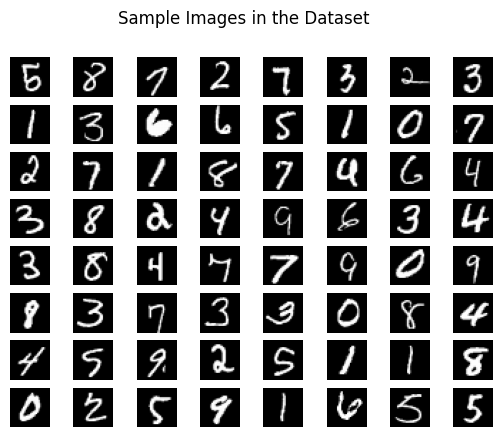

In [8]:
images, labels = next(iter(train_data))
plt.figure(figsize=(40, 40))
fig, ax = plt.subplots()
for i in range(64):
    plt.subplot(8, 8, i+1)
    plt.imshow(images[i].numpy().squeeze(), cmap='gray')
    plt.axis('off')
fig.delaxes(ax)
plt.suptitle("Sample Images in the Dataset")
plt.show()

In [6]:
class MLP(nn.Module):
    def __init__(self):
        super(MLP,self).__init__()
        self.fc1=nn.Linear(28*28,30)
        self.fc2=nn.Linear(30,20)
        self.fc3= nn.Linear(20,10)
    
    def forward(self,x):
        x = x.view(-1,28*28)
        x = nn.functional.relu(self.fc1(x))
        x = nn.functional.relu(self.fc2(x))
        x= self.fc3(x)
        return x
    
    def get_activations(self,x):
        x = x.view(-1,28*28)
        x = torch.relu(self.fc1(x))
        return torch.relu(self.fc2(x))

In [15]:
model = MLP()
criteria= nn.CrossEntropyLoss()
untrained = copy.deepcopy(model)

In [74]:
if torch.cuda.is_available():
    device = torch.device("cuda")
    print(f"GPU is available. Using device: {torch.cuda.get_device_name(0)}")
    model = model.to(device)
    criteria = criteria.to(device)
else:
    device = torch.device("cpu")
    print("GPU not available. Using the CPU.")


GPU is available. Using device: NVIDIA GeForce RTX 3050 Laptop GPU


In [75]:
total = 0
losses = []
optimizer = optim.Adam(model.parameters(),lr= 0.001)
for e in range(100):
    for img, label in train_data:
        img = img.to(device)
        label = label.to(device)

        total += len(img)

        optimizer.zero_grad()
        answers = model(img)
        loss = criteria(answers, label)
        loss.backward()
        optimizer.step()

        losses.append(loss.item())

    print(f"Epoch {e+1} Loss: {loss.item()}")

print("Total Images are:", total / 100)


Epoch 1 Loss: 0.11647403240203857
Epoch 2 Loss: 0.07567903399467468
Epoch 3 Loss: 0.05152043327689171
Epoch 4 Loss: 0.005493838805705309
Epoch 5 Loss: 0.03396805375814438
Epoch 6 Loss: 0.03868184611201286
Epoch 7 Loss: 0.06760415434837341
Epoch 8 Loss: 0.18335340917110443
Epoch 9 Loss: 0.004597907420247793
Epoch 10 Loss: 0.033029962331056595
Epoch 11 Loss: 0.0035007724072784185
Epoch 12 Loss: 0.10293430835008621
Epoch 13 Loss: 0.011621342040598392
Epoch 14 Loss: 0.02813798189163208
Epoch 15 Loss: 0.020074134692549706
Epoch 16 Loss: 0.03857576102018356
Epoch 17 Loss: 0.05337035283446312
Epoch 18 Loss: 0.02167070098221302
Epoch 19 Loss: 0.07445454597473145
Epoch 20 Loss: 0.3266255855560303
Epoch 21 Loss: 0.02046520635485649
Epoch 22 Loss: 0.031225362792611122
Epoch 23 Loss: 0.052486639469861984
Epoch 24 Loss: 0.019802486523985863
Epoch 25 Loss: 0.04094373807311058
Epoch 26 Loss: 0.06245772913098335
Epoch 27 Loss: 0.022325534373521805
Epoch 28 Loss: 0.07149638235569
Epoch 29 Loss: 0.00580

Showing output on some test data

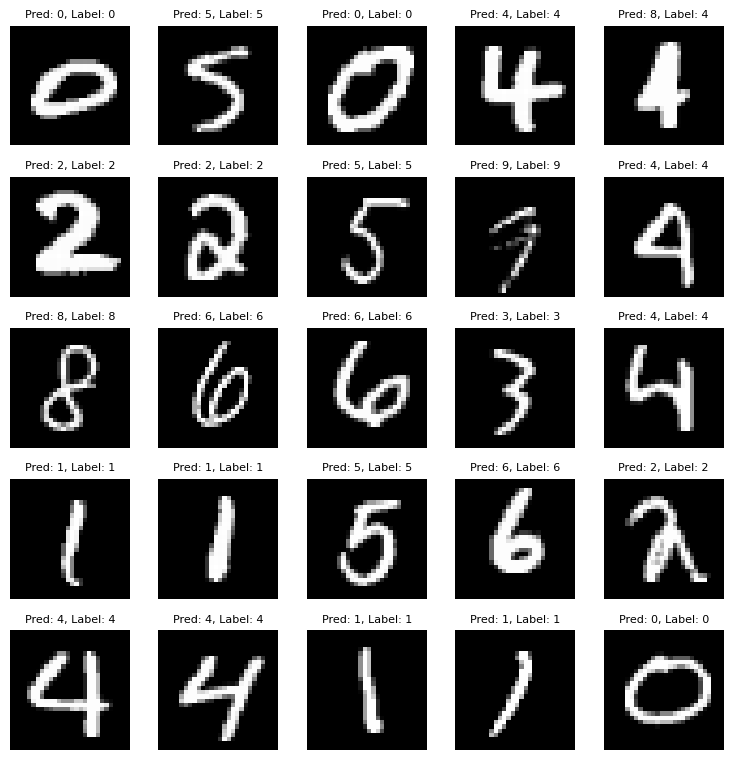

In [76]:
import matplotlib.pyplot as plt
import numpy as np
import torch


test_img, test_label = next(iter(test_data))


test_img = test_img.to(device)
test_label = test_label.to(device)


model.eval()
with torch.no_grad():
    fig, ax = plt.subplots(figsize=(8, 8))
    
    for i in range(25):
        
        output = model(test_img[i].unsqueeze(0)) 
        pred = torch.argmax(output, dim=1).item()
        
        img_cpu = test_img[i].detach().cpu().numpy().squeeze()
        label_cpu = test_label[i].detach().cpu().item()
        
        plt.subplot(5, 5, i + 1)
        plt.imshow(img_cpu, cmap="gray")
        plt.title(f'Pred: {pred}, Label: {label_cpu}', fontsize=8)
        plt.axis("off")

    plt.tight_layout()
    plt.delaxes(ax)
    plt.show()


In [77]:
model.eval()
y_pred=[]
y_label = []
with torch.no_grad():
    for img,label in test_data:
        img = img.to(device)
        label = label.to(device)

        answer = model(img.view(-1,28*28))
        prediction = torch.argmax(answer,dim=1)

        y_pred.append(prediction.cpu().numpy())
        y_label.append(label.cpu().numpy())

y_pred = np.concatenate(y_pred)
y_label = np.concatenate(y_label)
print(f"Shape of y_pred = {y_pred.shape}")
print(f"Shape of y_label = {y_label.shape}")

Shape of y_pred = (10000,)
Shape of y_label = (10000,)


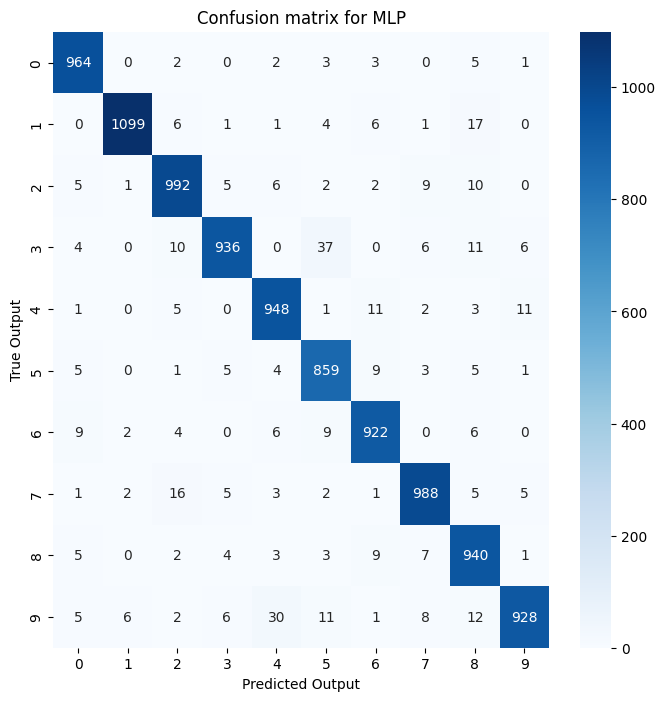

Accuracy for MLP = 95.76
F1 score for MLP = 0.9571707153462692


In [78]:
accuracy_mlp = ((y_pred == y_label).sum())/100
f1_mlp = f1_score(y_label,y_pred,average = "macro")
cm_mlp = confusion_matrix(y_label,y_pred)

plt.figure(figsize=(8,8))
sns.heatmap(cm_mlp,annot=True,fmt="d",cmap="Blues", xticklabels= np.unique(y_label),
        yticklabels= np.unique(y_label))
plt.xlabel("Predicted Output")
plt.ylabel("True Output")
plt.title("Confusion matrix for MLP")
plt.show()
print(f"Accuracy for MLP = {accuracy_mlp}")
print(f"F1 score for MLP = {f1_mlp}")

Training and seeing output of Random Forest model

In [ ]:
# train_features_new = (train_features * 0.5) + 0.5
# test_features_new = (test_features * 0.5) + 0.5

In [51]:
random_forest = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)
random_forest.fit(train_features, train_label)
y_pred = random_forest.predict(test_features)

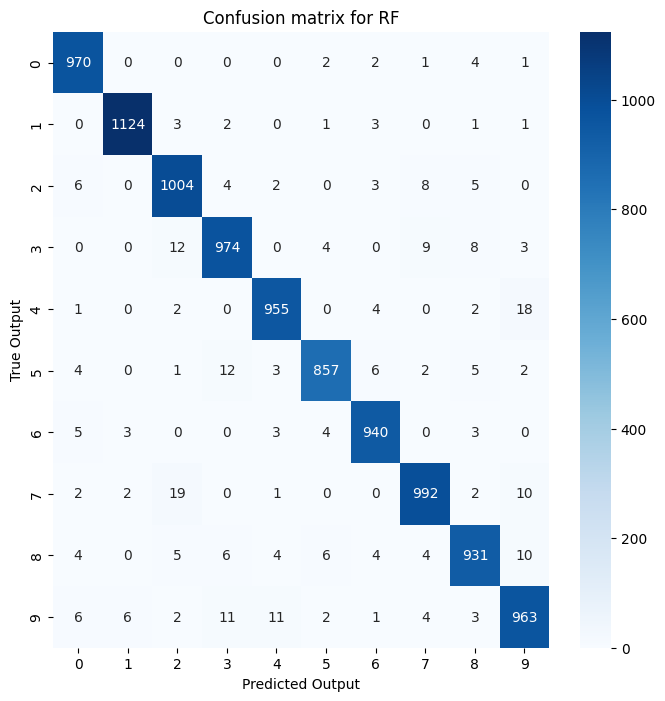

Accuracy for RF = 97.1
F1 score for RF = 0.9707840365056887


In [52]:
accuracy_rf = (y_pred == test_label).mean()
f1_rf = f1_score(test_label, y_pred, average="macro")
cm_rf = confusion_matrix(test_label, y_pred)

accuracy_rf = ((y_pred == test_label).sum())/100
f1_rf = f1_score(test_label,y_pred,average = "macro")
cm_rf = confusion_matrix(test_label,y_pred)

plt.figure(figsize=(8,8))
sns.heatmap(cm_rf,annot=True,fmt="d",cmap="Blues", xticklabels= np.unique(y_label),
        yticklabels= np.unique(y_label))
plt.xlabel("Predicted Output")
plt.ylabel("True Output")
plt.title("Confusion matrix for RF")
plt.show()
print(f"Accuracy for RF = {accuracy_rf}")
print(f"F1 score for RF = {f1_rf}")

Training and testing using Logistic Regressiion

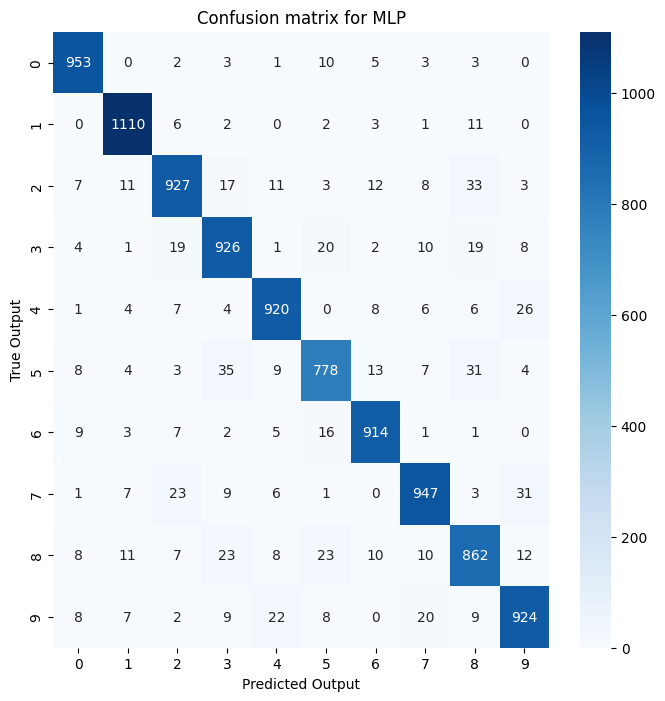

Accuracy for Logistic Regression = 92.61
F1 score for MLP = 0.9251180087388917


In [53]:
logistic = LogisticRegression(max_iter = 1000)
logistic.fit(train_features,train_label)
y_pred = logistic.predict(test_features)

accuracy_lr = ((y_pred == test_label).sum())/100
f1_lr = f1_score(test_label,y_pred,average = "macro")
cm_lr = confusion_matrix(test_label,y_pred)

plt.figure(figsize=(8,8))
sns.heatmap(cm_lr,annot=True,fmt="d",cmap="Blues", xticklabels= np.unique(test_label),
        yticklabels= np.unique(test_label))
plt.xlabel("Predicted Output")
plt.ylabel("True Output")
plt.title("Confusion matrix for MLP")
plt.show()
print(f"Accuracy for Logistic Regression = {accuracy_lr}")
print(f"F1 score for MLP = {f1_lr}")

In [ ]:
def features20(model, data):
    activations = []
    labels = []
    device = next(model.parameters()).device  
    model.eval()

    with torch.no_grad():
        for img, label in data:
            img = img.to(device)              
            feats = model.get_activations(img)
            activations.append(feats.cpu())   
            labels.append(label.cpu())        

    activations = torch.cat(activations, dim=0)
    labels = torch.cat(labels, dim=0)

    return activations, labels


In [80]:
model = model.cpu()
untrained = untrained.cpu()
untrained_activation, untrained_answer= features20(untrained,test_data)
trained_activation, trained_answer = features20(model,test_data)

print(f"Shape of untrained activations = {untrained_activation.shape}")
print(f"Shape of trained activations = {trained_activation.shape}")

Shape of untrained activations = torch.Size([10000, 20])
Shape of trained activations = torch.Size([10000, 20])


In [ ]:
from sklearn.preprocessing import StandardScaler
scaled_trained = StandardScaler().fit_transform(trained_activation)
scaled_untrained = StandardScaler().fit_transform(untrained_activation)
tsne_trained = TSNE(n_components=2, perplexity=50, learning_rate=200, random_state=42).fit_transform(scaled_trained)
tsne_untrained = TSNE(n_components=2, perplexity=50, learning_rate=200, random_state=42).fit_transform(scaled_untrained)


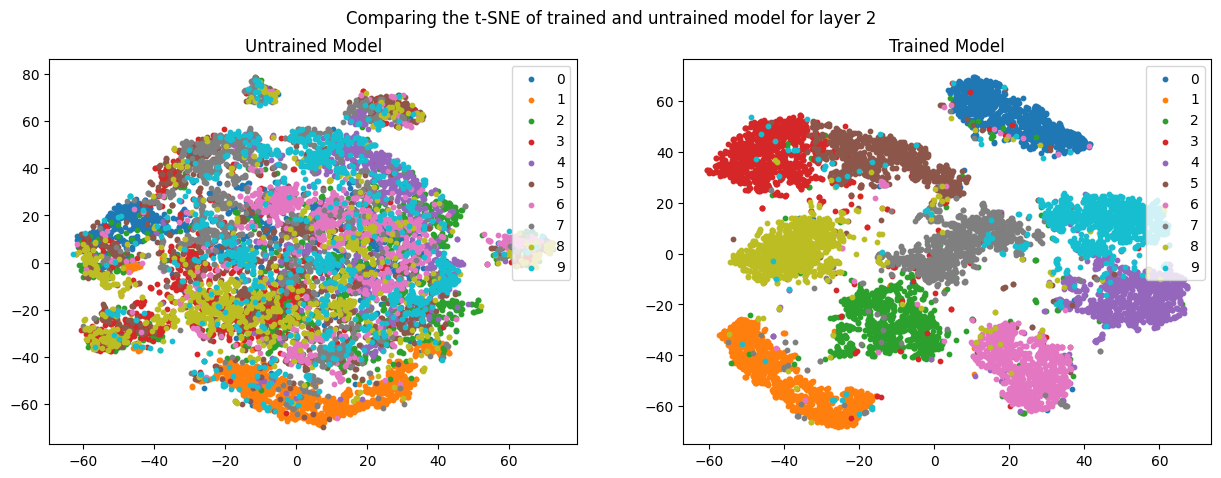

In [84]:
plt.figure(figsize=(15, 5))
plt.subplot(1, 2, 1)
for i in range(10):
    plt.scatter(tsne_untrained[untrained_answer == i, 0], tsne_untrained[untrained_answer == i, 1], s=10, label=i)
plt.title('Untrained Model')
plt.legend()
plt.subplot(1, 2, 2)
for i in range(10):
    plt.scatter(tsne_trained[trained_answer == i, 0], tsne_trained[trained_answer == i, 1], s=10, label=i)
plt.legend()
plt.title('Trained Model')
plt.suptitle('Comparing the t-SNE of trained and untrained model for layer 2')
plt.show()

Fashion MNIST Dataset

In [87]:
testing_dataset_fashion = datasets.FashionMNIST('./dataset_q3',  train=False, transform=transformation,download=True)
fashion = torch.utils.data.DataLoader(testing_dataset_fashion, batch_size=64, shuffle=True)

<Figure size 4000x4000 with 0 Axes>

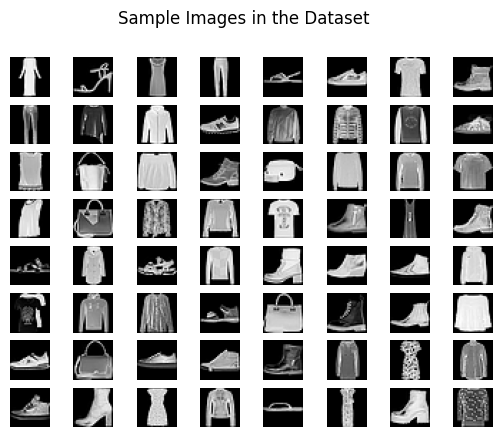

In [88]:
images, labels = next(iter(fashion))
plt.figure(figsize=(40, 40))
fig, ax = plt.subplots()
for i in range(64):
    plt.subplot(8, 8, i+1)
    plt.imshow(images[i].numpy().squeeze(), cmap='gray')
    plt.axis('off')
fig.delaxes(ax)
plt.suptitle("Sample Images in the Dataset")
plt.show()

In [92]:
model.to(device)
model.eval()
y_pred_fashion=[]
y_label_fashion = []

with torch.no_grad():
    for img,label in fashion:
        img = img.to(device)
        label = label.to(device)

        answer = model(img.view(-1,28*28))
        prediction = torch.argmax(answer,dim=1)

        y_pred_fashion.append(prediction.cpu().numpy())
        y_label_fashion.append(label.cpu().numpy())

y_pred_fashion = np.concatenate(y_pred_fashion)
y_label_fashion = np.concatenate(y_label_fashion)
print(f"Shape of y_pred = {y_pred_fashion.shape}")
print(f"Shape of y_label = {y_label_fashion.shape}")

Shape of y_pred = (10000,)
Shape of y_label = (10000,)


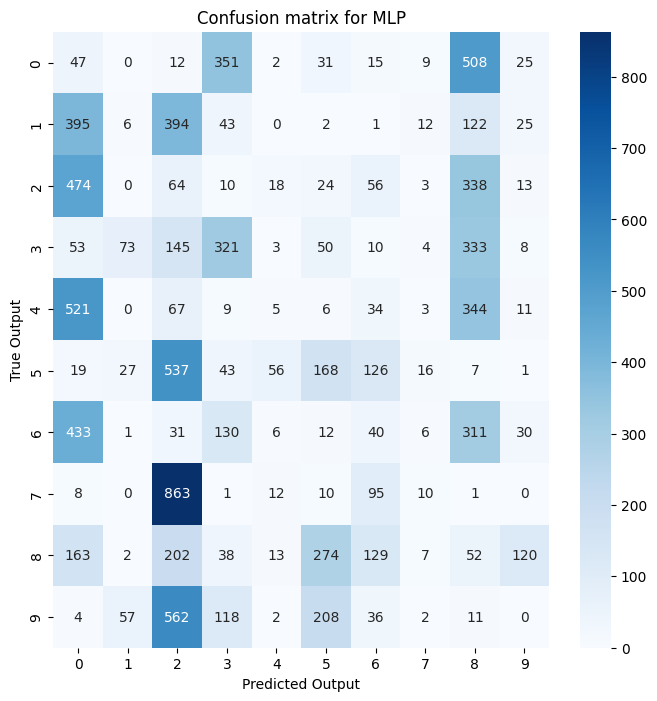

Accuracy for MLP = 7.13%
F1 score for MLP = 0.06865932132970115


In [94]:
accuracy_fashion = ((y_pred_fashion == y_label_fashion).mean())
f1_fashion = f1_score(y_label_fashion,y_pred_fashion,average = "macro")
cm_fashion = confusion_matrix(y_label_fashion,y_pred_fashion)

plt.figure(figsize=(8,8))
sns.heatmap(cm_fashion,annot=True,fmt="d",cmap="Blues", xticklabels= np.unique(y_label_fashion),
        yticklabels= np.unique(y_label_fashion))
plt.xlabel("Predicted Output")
plt.ylabel("True Output")
plt.title("Confusion matrix for MLP")
plt.show()
print(f"Accuracy for MLP = {accuracy_fashion*100}%")
print(f"F1 score for MLP = {f1_fashion}")

In [105]:
# model.cpu()
fashion_features , fashion_answers = features20(model,fashion)
tsne_fashion = TSNE(n_components=2, perplexity=50, learning_rate=200, random_state=42).fit_transform(fashion_features)

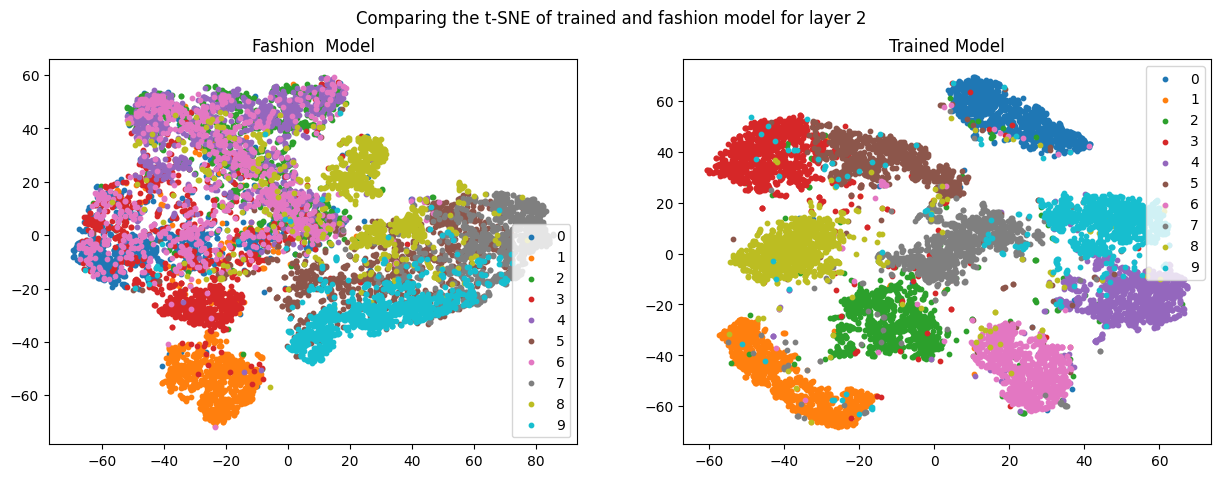

In [106]:
plt.figure(figsize=(15, 5))
plt.subplot(1, 2, 1)
for i in range(10):
    plt.scatter(tsne_fashion[fashion_answers == i, 0],tsne_fashion[fashion_answers == i, 1], s=10, label=i)
plt.title('Fashion  Model')
plt.legend()
plt.subplot(1, 2, 2)
for i in range(10):
    plt.scatter(tsne_trained[trained_answer == i, 0], tsne_trained[trained_answer == i, 1], s=10, label=i)
plt.legend()
plt.title('Trained Model')
plt.suptitle("Comparing the t-SNE of trained and fashion model for layer 2")
plt.show()